In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# 问题：求解 1D Poisson 方程
# -u''(x) = f(x),  x ∈ [0, 1]
# 边界条件: u(0) = 0, u(1) = 0
#
# 我们选 f(x) = π² * sin(πx)
# 这样解析解是 u(x) = sin(πx)，方便验证网络学得对不对

def true_solution(x):
    return torch.sin(torch.pi * x)

def source_term(x):
    """f(x) = π² * sin(πx)，即 -u''(x)"""
    return (torch.pi ** 2) * torch.sin(torch.pi * x)

print("问题: -u''(x) = π²sin(πx), u(0)=0, u(1)=0")
print("解析解: u(x) = sin(πx)")


问题: -u''(x) = π²sin(πx), u(0)=0, u(1)=0
解析解: u(x) = sin(πx)


In [8]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = PINN()
print(model)


PINN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [9]:
def compute_loss(model, x_interior, x_boundary):
    """
    PINN 的损失 = 物理损失 + 边界损失

    物理损失: 让 -u''(x) 尽量等于 f(x)
    边界损失: 让 u(0)=0, u(1)=0
    """
    # --- 物理损失 ---
    x_interior.requires_grad_(True)
    u = model(x_interior)

    # 求 du/dx
    du_dx = torch.autograd.grad(
        u, x_interior,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    # 求 d²u/dx²
    d2u_dx2 = torch.autograd.grad(
        du_dx, x_interior,
        grad_outputs=torch.ones_like(du_dx),
        create_graph=True
    )[0]

    # 物理方程残差: -u''(x) - f(x) 应该 = 0
    f = source_term(x_interior)
    physics_residual = -d2u_dx2 - f
    loss_physics = torch.mean(physics_residual ** 2)

    # --- 边界损失 ---
    u_boundary = model(x_boundary)
    loss_boundary = torch.mean(u_boundary ** 2)  # u(0)=0, u(1)=0

    return loss_physics, loss_boundary

print("损失函数定义完成")
print("物理损失: MSE(-u'' - f)")
print("边界损失: MSE(u(边界) - 0)")


损失函数定义完成
物理损失: MSE(-u'' - f)
边界损失: MSE(u(边界) - 0)


In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 采样点
n_interior = 10  # 内部点数量
n_epochs = 3000

losses = []

for epoch in range(n_epochs):
    # 每次随机采样内部点（这是 PINN 的常见做法）
    x_interior = torch.rand(n_interior, 1)  # [0, 1] 之间随机点
    x_boundary = torch.tensor([[0.0], [1.0]])  # 边界点

    loss_physics, loss_boundary = compute_loss(model, x_interior, x_boundary)

    # 总损失 = 物理损失 + 权重 * 边界损失
    loss = loss_physics + 10 * loss_boundary  # 边界条件给更大权重

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d} | Loss: {loss.item():.6f} | "
              f"Physics: {loss_physics.item():.6f} | "
              f"Boundary: {loss_boundary.item():.6f}")

print("\n训练完成!")


Epoch  500 | Loss: 0.009036 | Physics: 0.007164 | Boundary: 0.000187
Epoch 1000 | Loss: 0.001664 | Physics: 0.001383 | Boundary: 0.000028
Epoch 1500 | Loss: 0.001770 | Physics: 0.001487 | Boundary: 0.000028
Epoch 2000 | Loss: 0.001148 | Physics: 0.001086 | Boundary: 0.000006
Epoch 2500 | Loss: 0.002059 | Physics: 0.001882 | Boundary: 0.000018
Epoch 3000 | Loss: 0.001001 | Physics: 0.000700 | Boundary: 0.000030

训练完成!


C:\Users\inf27\AppData\Local\Temp\ipykernel_10184\661676275.py:29: UserWarning: Glyph 27714 (\N{CJK UNIFIED IDEOGRAPH-6C42}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inf27\AppData\Local\Temp\ipykernel_10184\661676275.py:29: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inf27\AppData\Local\Temp\ipykernel_10184\661676275.py:29: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inf27\AppData\Local\Temp\ipykernel_10184\661676275.py:29: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inf27\AppData\Local\Temp\ipykernel_10184\661676275.py:29: UserWarning: Glyph 26512 (\N{CJK UNIFIED IDEOGRAPH-6790}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\inf27\AppData\Local\Temp\ipykernel_10184\661676275.py:29: UserWarning: Glyph 39044 (\N{CJK 

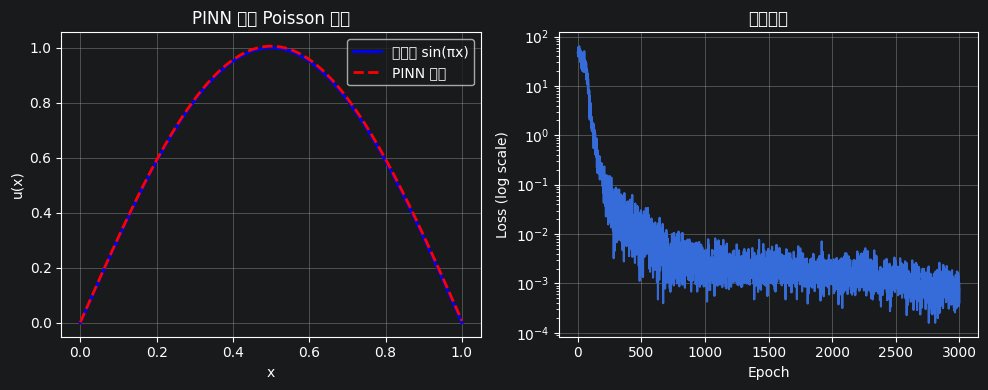

最大误差: 0.007564
平均误差: 0.005635


In [11]:
# 对比网络预测 vs 解析解
x_test = torch.linspace(0, 1, 100).reshape(-1, 1)

with torch.no_grad():
    u_pred = model(x_test).numpy()

u_exact = true_solution(x_test).numpy()

plt.figure(figsize=(10, 4))

# 左图：解的对比
plt.subplot(1, 2, 1)
plt.plot(x_test.numpy(), u_exact, 'b-', label='解析解 sin(πx)', linewidth=2)
plt.plot(x_test.numpy(), u_pred, 'r--', label='PINN 预测', linewidth=2)
plt.xlabel('x')
plt.ylabel('u(x)')
plt.title('PINN 求解 Poisson 方程')
plt.legend()
plt.grid(True)

# 右图：训练损失曲线
plt.subplot(1, 2, 2)
plt.semilogy(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('训练损失')
plt.grid(True)

plt.tight_layout()
plt.show()

# 计算误差
error = np.abs(u_pred - u_exact)
print(f"最大误差: {error.max():.6f}")
print(f"平均误差: {error.mean():.6f}")


In [6]:
print("""
=== PINN 的三个组成部分 ===

1. 神经网络: 用来近似未知函数 u(x)
   - 输入: 坐标 x
   - 输出: 函数值 u(x)

2. 物理损失: 把 u(x) 代入物理方程，残差越小越好
   - 用 autograd 求 u 的各阶导数
   - 计算 PDE 残差: -u''(x) - f(x)
   - 不需要标注数据！物理方程本身就是监督信号

3. 边界/数据损失: 满足已知条件
   - 边界条件: u(0)=0, u(1)=0
   - 如果有观测数据，也可以加数据损失

总损失 = λ₁ × 物理损失 + λ₂ × 边界损失 + λ₃ × 数据损失
""")



=== PINN 的三个组成部分 ===

1. 神经网络: 用来近似未知函数 u(x)
   - 输入: 坐标 x
   - 输出: 函数值 u(x)

2. 物理损失: 把 u(x) 代入物理方程，残差越小越好
   - 用 autograd 求 u 的各阶导数
   - 计算 PDE 残差: -u''(x) - f(x)
   - 不需要标注数据！物理方程本身就是监督信号

3. 边界/数据损失: 满足已知条件
   - 边界条件: u(0)=0, u(1)=0
   - 如果有观测数据，也可以加数据损失

总损失 = λ₁ × 物理损失 + λ₂ × 边界损失 + λ₃ × 数据损失

